### Step 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### Step 2: Load Dataset

In [81]:
df = pd.read_excel('./data/HousePricePrediction.xlsx')

In [82]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [83]:
df.shape

(2919, 13)

### Step 3: Exploaring Data

In [6]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [9]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [11]:
obj_list = df.select_dtypes(include=np.object_).columns
int_list = df.select_dtypes(include=np.int64).columns
float_list = df.select_dtypes(include=np.float64).columns

In [84]:
print('Categorical variables:', len(obj_list), '\nInteger variables:', len(int_list), '\nFloat variables:', len(float_list))

Categorical variables: 4 
Integer variables: 6 
Float variables: 3


<Axes: >

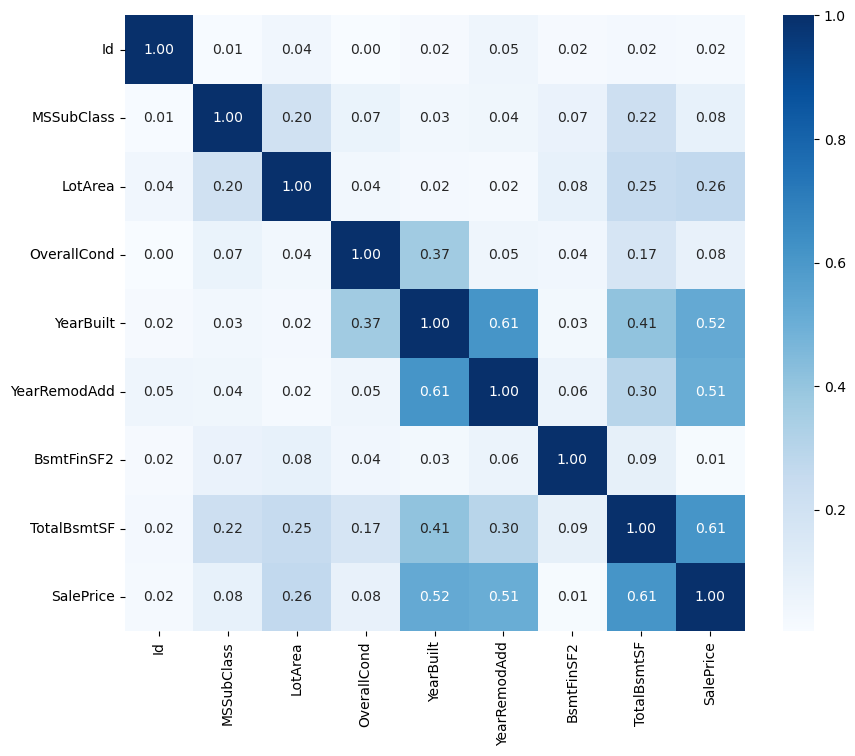

In [85]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr().abs(),
    annot=True,
    cmap=plt.cm.Blues,
    fmt='.2f'
)

<Axes: >

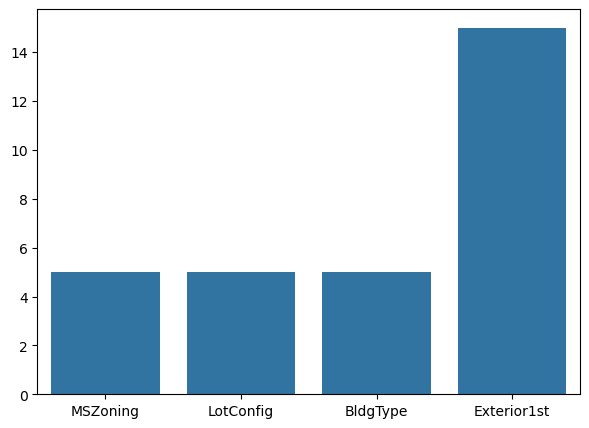

In [30]:
plt.figure(figsize=(7, 5))
sns.barplot(df[obj_list].nunique())

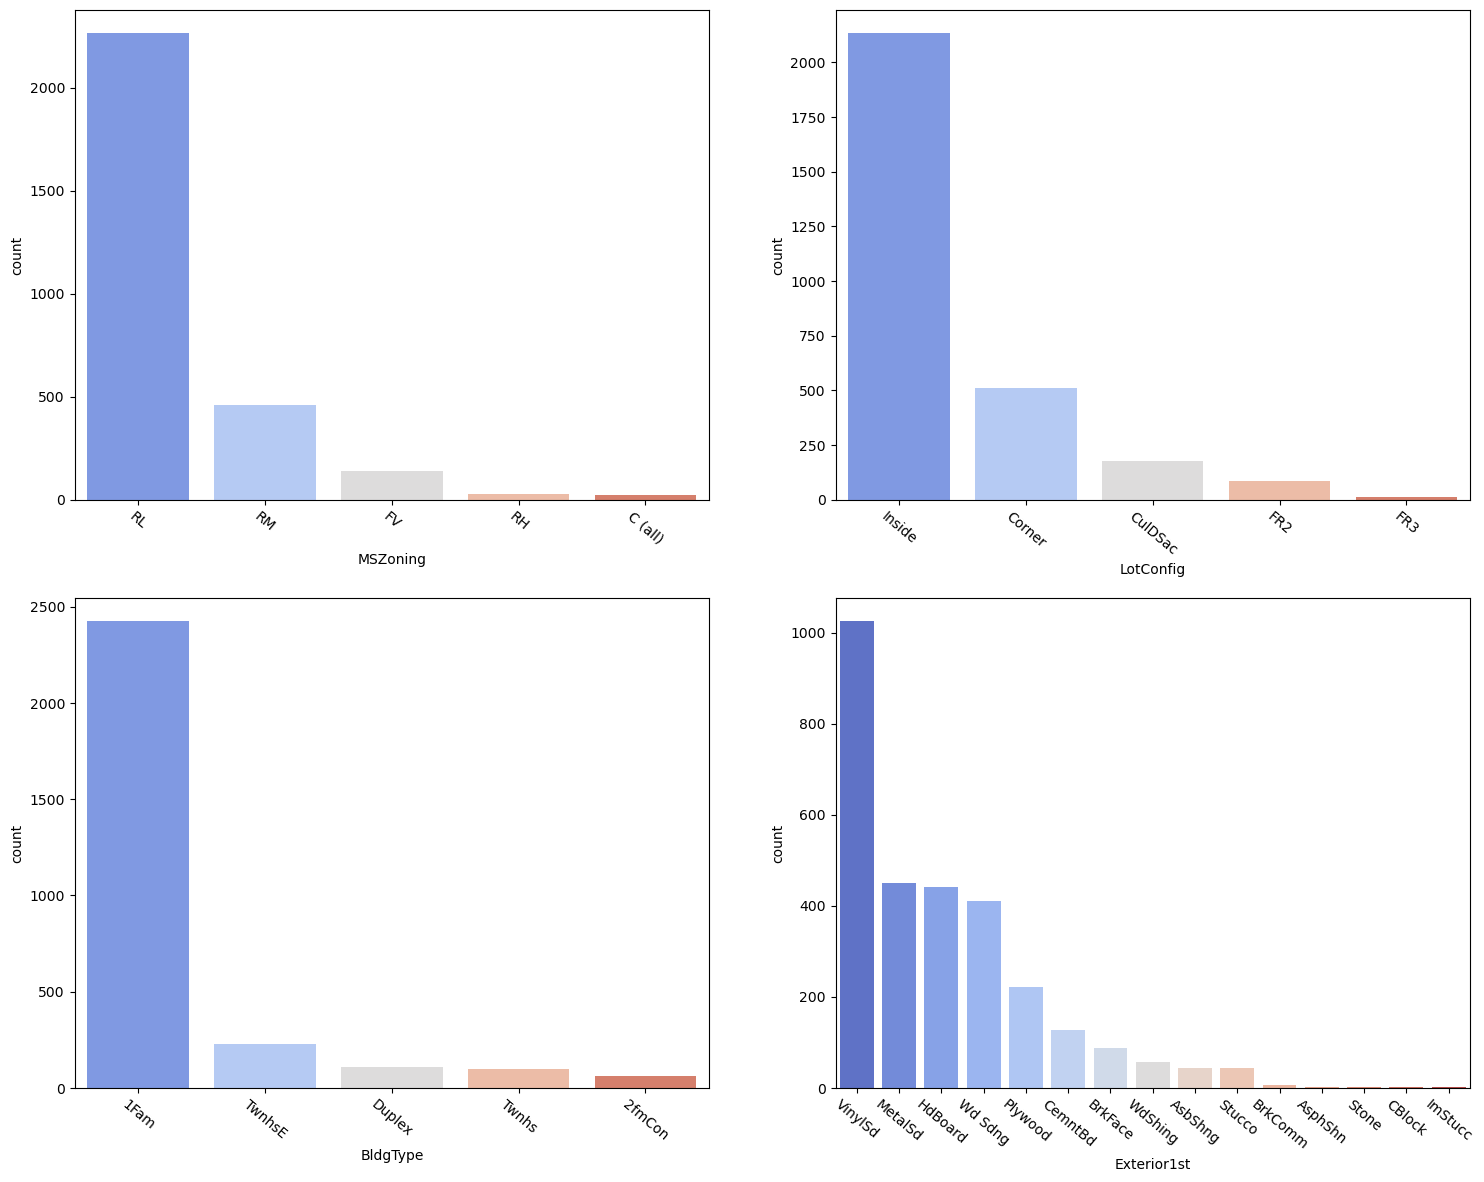

In [86]:
plt.figure(figsize=(18, 14))
for i, col in enumerate(obj_list):
    plt.subplot(2, 2, i+1)
    sns.barplot(df[col].value_counts(), palette='coolwarm', )
    plt.xticks(rotation=-40)

### Step 4: Feature Engineering

In [88]:
df.drop(['Id'], axis=1, inplace=True)

In [89]:
df['SalePrice'] = df['SalePrice'].fillna(df['SalePrice'].mean())

In [94]:
df.dropna(inplace=True, ignore_index=True)

In [98]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [99]:
ohe_df = pd.DataFrame(ohe.fit_transform(df[obj_list]), columns=ohe.get_feature_names_out(),)

In [100]:
df.drop(obj_list, axis=1, inplace=True)

In [101]:
df = pd.concat([df, ohe_df], axis=1)

### Step 5: Preparing Data

In [103]:
features = df.drop(['SalePrice'], axis=1)
target = df['SalePrice']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

### Step 6: Building & Training Model

In [105]:
models = [
    SVR(),
    RandomForestRegressor(n_estimators=10),
    LinearRegression()
]

In [107]:
for model in models:
    model.fit(X_train, y_train)

### Step 7: Evaluate Model

In [116]:
for model in models:
    y_pred = model.predict(X_test)
    print(f'{model.__class__.__name__}:')
    print('train mean absolute error:', round(100 * metrics.mean_absolute_percentage_error(y_train, model.predict(X_train)), 2), '%')
    print('test mean absolute error:', round(100 * metrics.mean_absolute_percentage_error(y_test, y_pred), 2), '%')
    print('--------------------')    

SVR:
train mean absolute error: 17.58 %
test mean absolute error: 20.69 %
--------------------
RandomForestRegressor:
train mean absolute error: 7.09 %
test mean absolute error: 20.63 %
--------------------
LinearRegression:
train mean absolute error: 18.34 %
test mean absolute error: 20.02 %
--------------------
